In [1]:
!pip install wilds matplotlib torch torchvision terratorch umap-learn seaborn scikit-learn matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import ClusteringPipeline
import Student
# ---------------------------------------------------------
#  Simplified DataLoader
# ---------------------------------------------------------
import torch
from pathlib import Path
from PIL import Image
import torchvision.transforms as T

my_root_path = "/mnt/windows/Users/kevin/Downloads/"
def get_input(idx):
    """
    Returns an RGB image for a given idx, ensuring file handles are safely closed.
    """
    file_path = Path(my_root_path + 'fmow_v1.1') / 'images' / f'rgb_img_{idx}.png'
    # The 'with' block guarantees the file on disk is closed the microsecond we are done
    with Image.open(file_path) as img:
        # .convert() creates the standalone memory object we need
        return img.convert('RGB')

preprocessImagenet = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


In [3]:
import FoundationModel
pipeline = ClusteringPipeline.ClusteringPipeline()
FM = FoundationModel.FoundationModel()

# Assuming you've updated sample_dataset to just take the top 15 classes if no specific list is given:
df_full = pipeline.get_dataset()
df_sample = pipeline.sample_dataset(df_full, samples_per_class=200) # Ensure 15 distinct classes are kept

# 2. Extract Embeddings
df_base = pipeline.get_embeddings(df_sample, FM, get_input, preprocessImagenet, save_path="./dino",compute_stats=False)

class_to_concept_mapping = {
    # Concept 1
    "stadium": 1,
    "swimming_pool": 1,
    "multi-unit_residential": 1,
    "recreational_facility": 1,
    "park": 1,

    # Concept 2
    "airport_hangar": 2,
    "airport_terminal": 2,
    "crop_field": 2,
    "amusement_park": 2,
    "military_facility": 2,

    # Concept 3
    "nuclear_powerplant": 3,
    "airport": 3,
    "runway": 3,
    "aquaculture": 3,
    "wind_farm": 3
}

# Apply it to your dataframe
df_base = pipeline.create_concepts(df_base, class_to_concept_mapping)
# 4. PRE-SHUFFLE ONCE WITH A FIXED SEED.
# This guarantees every grid search config sees the exact same sequence.
df_stream = df_base.sample(frac=1, random_state=42).reset_index(drop=True)
# 5. ORDER BY CONCEPT
df_stream = df_stream.sort_values(by='concept').reset_index(drop=True)

embedding_dim_base = len(df_stream['embedding'].iloc[0])

/home/kevinthomaj/PyCharmMiscProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in /home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/kevinthomaj/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


--- Sampling 200 images per class ---
Found saved dataset at ./dino. Loading from disk...
Distribution of images across the new macro-classes:
concept
3    1000
2    1000
1    1000
Name: count, dtype: int64


In [4]:
#this will be filled with the printed output statistics of get_embeddings
preprocessFMOW = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4279618263244629, 0.4296368956565857, 0.39697331190109253],
                         std =[0.25068026781082153, 0.2403821349143982, 0.2443935126066208]),
])

In [5]:
from torch import nn

class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes=62):
        super(LinearProbe, self).__init__()
        # Nessun hidden layer, solo una proiezione diretta
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

In [6]:
torch.set_num_threads(4)
total_classes = len(df_stream['category'].unique())

In [7]:
from sklearn.model_selection import ParameterGrid

# Shared base hyperparameters
base_params = {
    'lr': [1e-3],
    'batch_size': [25],
    'epochs_per_batch': [1]
}

# 1. Online Without Distillation
grid_no_distill = list(ParameterGrid({**base_params}))

# 2. Online with Linear Distillation
grid_linear_distill = list(ParameterGrid({
    **base_params,
    'distill_weight': [1.0]
}))

# 3. Online with MLP Distillation
grid_mlp_distill = list(ParameterGrid({
    **base_params,
    'distill_weight': [1.0],
    'hidden_dim': [512]
}))

# 4. Online with Linear Distillation + EMA Teacher
grid_linear_ema = list(ParameterGrid({
    **base_params,
    'distill_weight': [0.5, 1.0],
    'ema_alpha': [0.99, 0.999]  # Common EMA momentum values
}))

# 5. Online with MLP Distillation + EMA Teacher
grid_mlp_ema = list(ParameterGrid({
    **base_params,
    'distill_weight': [0.5, 1.0],
    'hidden_dim': [256, 512],
    'ema_alpha': [0.99, 0.999]
}))

# 6. Linear Probing (Upper Bound)
grid_linear_probing = list(ParameterGrid({
    'lr': [1e-3], # Linear probing usually tolerates higher LRs
    'batch_size': [25],
    'epochs_per_batch': [1]
}))

/home/kevinthomaj/PyCharmMiscProject/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(



Starting Experiment Suite: 3_Pretrained_MLPDistillation

--- Running Config 1/1: {'batch_size': 25, 'distill_weight': 1.0, 'epochs_per_batch': 1, 'hidden_dim': 512, 'lr': 0.001} ---


Stream:   0%|          | 0/3000 [00:00<?, ?it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...


Stream:   1%|          | 31/3000 [00:02<07:03,  7.01it/s]

...

Stream:  99%|█████████▉| 2979/3000 [04:43<00:02,  8.05it/s]

Loss output student: 1.3154
Loss distillation: 0.9517
Sample visti: 975 | Classi corrette: 142 | Accuratezza Cumulata: 14.56%


Stream: 100%|██████████| 3000/3000 [04:45<00:00, 10.51it/s]

Loss output student: 1.8304
Loss distillation: 0.8077
Sample visti: 1000 | Classi corrette: 149 | Accuratezza Cumulata: 14.90%

--- Fine Stream | Accuratezza Finale: 14.90% ---



Plotting results for 3_Pretrained_MLPDistillation...


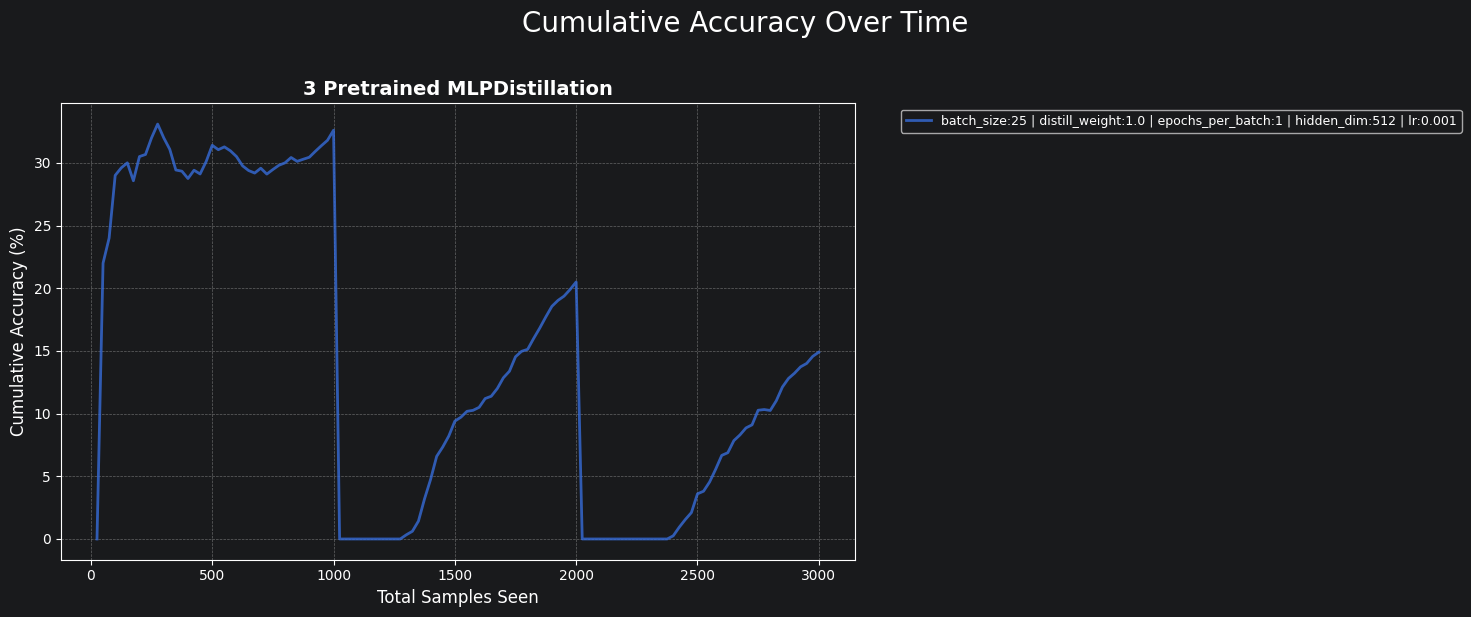


Starting Experiment Suite: 0a_NoPretrain_NoDistillation

--- Running Config 1/1: {'batch_size': 25, 'epochs_per_batch': 1, 'lr': 0.001} ---


/home/kevinthomaj/PyCharmMiscProject/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
Stream:   0%|          | 2/3000 [00:00<03:18, 15.13it/s]


--- DRIFT DETECTED: Transitioning from Concept 0 to Concept 1 ---
Resetting accuracy metrics...


Stream:   1%|          | 29/3000 [00:03<11:59,  4.13it/s]

Loss output student: 3.2269
Sample visti: 25 | Classi corrette: 0 | Accuratezza Cumulata: 0.00%


...

Stream:  57%|█████▋    | 1705/3000 [1:59:16<03:05,  6.98it/s]

Loss output student: 1.4785
Sample visti: 700 | Classi corrette: 113 | Accuratezza Cumulata: 16.14%


Stream:  58%|█████▊    | 1728/3000 [1:59:19<03:12,  6.61it/s]

Loss output student: 1.3935
Sample visti: 725 | Classi corrette: 123 | Accuratezza Cumulata: 16.97%


Stream:  58%|█████▊    | 1746/3000 [1:59:19<01:06, 18.84it/s]

In [ ]:
import gc
import torch
import torch.nn as nn
from FeatureDistillation import LinearReluDistiller, MLPDistiller
from Student import Student
import traceback

# ==========================================
# GRID SEARCH EXECUTION LOOP
# ==========================================
def run_grid_search(df_stream, embedding_dim_base, pipeline, transform_imagenet, transform_fmow):
    total_classes = len(df_stream['category'].unique())

    # We define new names so the logic easily knows if it's pretrained or not, and what distillation to use.
    experiments = [
        ("3_Pretrained_MLPDistillation", grid_mlp_distill),
        ("0a_NoPretrain_NoDistillation", grid_no_distill),
        ("0b_NoPretrain_LinearDistillation", grid_linear_distill),
        ("0c_NoPretrain_MLPDistillation", grid_mlp_distill),

        ("1_Pretrained_NoDistillation", grid_no_distill),
        ("2_Pretrained_LinearDistillation", grid_linear_distill),


        ("6_Linear_Probing_UB", grid_linear_probing)
    ]

    for exp_name, param_grid in experiments:
        print(f"\n{'='*60}\nStarting Experiment Suite: {exp_name}\n{'='*60}")

        suite_results = []

        for idx, params in enumerate(param_grid):
            print(f"\n--- Running Config {idx+1}/{len(param_grid)}: {params} ---")

            # 1. Initialize Models & Assign Transforms Dynamically
            if "Linear_Probing" in exp_name:
                model = LinearProbe(num_classes=total_classes, input_dim=embedding_dim_base)
                current_transform = transform_imagenet
            elif "NoPretrain" in exp_name:
                model = Student(numberOfClasses=total_classes, pretrained=False)
                current_transform = transform_fmow
            else:
                model = Student(numberOfClasses=total_classes, pretrained=True)
                current_transform = transform_imagenet

            criterion = nn.CrossEntropyLoss()
            distillator = None

            # 2. Setup Distillators conditionally based on exp_name
            if "LinearDistillation" in exp_name:
                distillator = LinearReluDistiller(dimFeatureStudent=512, dimFeatureTeacher=embedding_dim_base)
            elif "MLPDistillation" in exp_name:
                distillator = MLPDistiller(
                    dimFeatureStudent=512,
                    dimFeatureTeacher=embedding_dim_base,
                    hiddenLayerSize=params.get('hidden_dim')
                )

            # 3. Setup Adam Optimizer (Reminder: Adam uses ~3x more RAM than SGD)
            trainable_params = list(model.parameters())
            if distillator is not None:
                trainable_params += list(distillator.parameters())

            optimizer = torch.optim.Adam(trainable_params, lr=params['lr'])

            # 4. Execute Streaming Pipeline
            try:
                if "Linear_Probing" in exp_name:
                    final_acc, history = pipeline.linear_probing_online(
                        classifier=model,
                        df=df_stream.copy(),
                        criterion=criterion,
                        optimizer=optimizer,
                        batch_size=params['batch_size'],
                        num_epochs_per_batch=params['epochs_per_batch']
                    )
                else:
                    final_acc, history = pipeline.train_online(
                        df=df_stream.copy(),
                        model=model,
                        criterion=criterion,
                        optimizer=optimizer,
                        get_input_fn=get_input,
                        transform_fn=current_transform,
                        target_col='category',
                        batch_size=params['batch_size'],
                        num_epochs_per_batch=params['epochs_per_batch'],
                        distillator=distillator,
                        distill_weight=params.get('distill_weight')
                        # EMA logic completely removed
                    )

                # Append to the suite-specific results
                suite_results.append({
                    'experiment_group': exp_name,
                    'config_id': f"{exp_name}_cfg{idx}",
                    'params': params,
                    'final_accuracy': final_acc,
                    'history': history
                })

            except Exception as e:
                print(f"[!] Failed on config {params}")
                traceback.print_exc()

            # 5. Strict Memory Cleanup between runs
            del model, optimizer, criterion, distillator
            gc.collect()

        # ==========================================
        # PLOT AND PURGE AFTER EACH SUITE
        # ==========================================
        print(f"\nPlotting results for {exp_name}...")
        pipeline.plot_performance_over_time(suite_results)

        # Purge the history data from RAM before starting the next experiment suite
        del suite_results
        gc.collect()

    print("\nAll experiments completed successfully!")

run_grid_search(df_stream, embedding_dim_base, pipeline, preprocessImagenet, preprocessFMOW)